In [4]:
import pandas as pd 


#loading the dataset
df = pd.read_csv(
    '../data/amazon_reviews.csv',
    engine='python',
    on_bad_lines='skip'
)


#show first 5 rows
df.head()


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       21214 non-null  str  
 1   Profile Link        21163 non-null  str  
 2   Country             21054 non-null  str  
 3   Review Count        21055 non-null  str  
 4   Review Date         21055 non-null  str  
 5   Rating              21055 non-null  str  
 6   Review Title        21055 non-null  str  
 7   Review Text         21055 non-null  str  
 8   Date of Experience  20947 non-null  str  
dtypes: str(9)
memory usage: 1.5 MB


In [6]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [7]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='str')

In [8]:
df.isnull().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [9]:
df = df.dropna(subset=['Rating','Review Text'])

In [10]:
df.isnull().sum()

Reviewer Name           0
Profile Link            0
Country                 1
Review Count            0
Review Date             0
Rating                  0
Review Title            0
Review Text             0
Date of Experience    108
dtype: int64

In [11]:
df['Rating'].unique()

<StringArray>
['Rated 1 out of 5 stars', 'Rated 5 out of 5 stars', 'Rated 2 out of 5 stars',
 'Rated 4 out of 5 stars', 'Rated 3 out of 5 stars']
Length: 5, dtype: str

In [12]:
df['Rating'] = df['Rating'].str.extract('(\d)').astype(int)

In [13]:
df['Rating'].head()

0    1
1    1
2    1
3    1
4    1
Name: Rating, dtype: int64

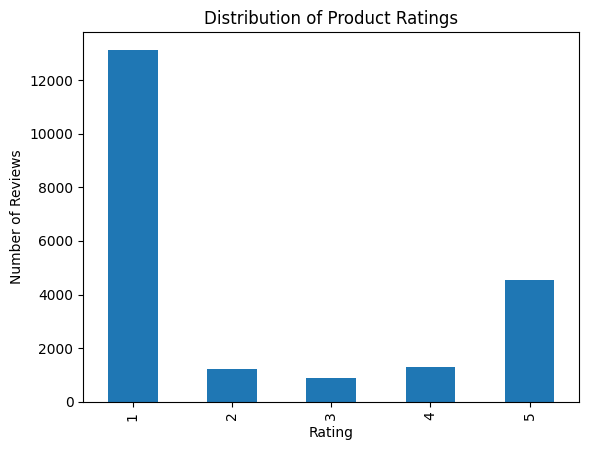

In [14]:
import matplotlib.pyplot as plt

rating_counts = df['Rating'].value_counts().sort_index()

rating_counts.plot(kind='bar')

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Product Ratings")

plt.show()

In [20]:
plt.savefig('../visuals/rating_chart.png')

<Figure size 640x480 with 0 Axes>

## Insights

- Most reviews are 1-star ratings.
- A significant number of users also gave 5-star ratings.
- Middle ratings (2, 3, 4) are comparatively low.
- This indicates polarized customer sentiment.

In [15]:
from textblob import TextBlob

# Function to classify sentiment
def get_sentiment(text):
    
    analysis = TextBlob(str(text))
    
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Review Text'].apply(get_sentiment)

# Show sample
df[['Review Text', 'Sentiment']].head()

,Review Text,Sentiment
0,"I registered on the website, tried to order a ...",Negative
1,Had multiple orders one turned up and driver h...,Negative
2,I informed these reprobates that I WOULD NOT B...,Negative
3,I have bought from Amazon before and no proble...,Negative
4,If I could give a lower rate I would! I cancel...,Neutral


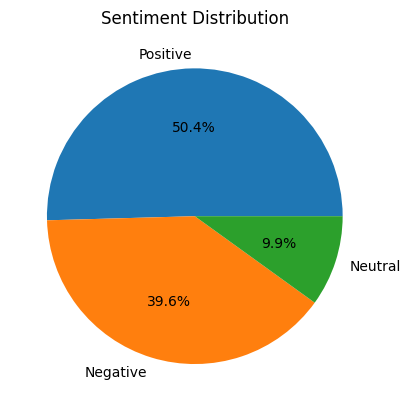

In [18]:
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'

)

plt.title("Sentiment Distribution")

plt.ylabel("")

plt.show()

## Sentiment Insights

- Positive reviews are slightly higher than negative reviews.
- A large percentage of users expressed dissatisfaction.
- Neutral reviews are comparatively fewer.
- Customer sentiment appears highly polarized.

In [19]:
plt.savefig('../visuals/sentiment_chart.png')

<Figure size 640x480 with 0 Axes>